# Banaskantha Potato Yield vs Weather — ML Modelling


Upload `B_K_Weather.xlsx` and `Gujarat_Potato_Data.csv`


In [3]:
!pip install -q openpyxl xgboost scikit-learn --upgrade

In [8]:
# Upload the two data files (skip this cell if running locally with files already in the working dir)
from google.colab import files
uploaded = files.upload()   # select B_K_Weather.xlsx and Gujarat_Potato_Data.csv

Saving B_K Weather.xlsx to B_K Weather (1).xlsx
Saving Banaskantha_Potato_Productivity_1995_2022.xlsx to Banaskantha_Potato_Productivity_1995_2022.xlsx


In [9]:
import pandas as pd, numpy as np, warnings, openpyxl
warnings.filterwarnings('ignore')

from sklearn.model_selection import LeaveOneOut, KFold, RandomizedSearchCV, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression, RFE
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

## Step 1 — Load daily weather, aggregate to Standard Meteorological Week (SMW)

In [10]:
wb = openpyxl.load_workbook('B_K Weather.xlsx', read_only=True, data_only=True)
ws = wb['Banaskantha_NASA_POWER_1996_202']
rows = list(ws.iter_rows(values_only=True))
wdf = pd.DataFrame(rows[1:], columns=rows[0])
wdf['Date'] = pd.to_datetime(wdf['Date'])
wdf['Year'] = wdf['Date'].dt.year
wdf['DOY']  = wdf['Date'].dt.dayofyear
# IMD Standard Meteorological Week: Week1 = Jan1-7 ... Week52 = Dec24-31
wdf['SMW'] = ((wdf['DOY']-1)//7 + 1).clip(upper=52)

weekly = wdf.groupby(['Year','SMW']).agg(
    TMAX=('T2M_MAX','mean'), TMIN=('T2M_MIN','mean'),
    RH=('RH2M','mean'), BSS=('BSS_hr','mean'), WS=('WS10M','mean')
).reset_index()
weekly.head()

,Year,SMW,TMAX,TMIN,RH,BSS,WS
0,1996,1,27.795714,12.740000,36.901429,8.306857,3.348571
1,1996,2,29.124286,12.901429,25.928571,8.878714,2.934286
2,1996,3,25.617143,8.878571,30.235714,9.274857,3.307143
3,1996,4,29.605714,12.652857,26.697143,9.966571,3.432857
4,1996,5,30.860000,11.080000,11.292857,9.887286,3.417143


## Step 2 — Load potato yield (Banaskantha), map SMW42-52 + SMW1-8 to each crop-year

In [11]:
py = pd.read_excel('Banaskantha_Potato_Productivity_1995_2022.xlsx', header=2)

py['StartYear'] = py['Year'].astype(int)
py = py.sort_values('StartYear').reset_index(drop=True)

season_weeks = list(range(42,53)) + list(range(1,9))   # SMW42-52 (yr1) + SMW1-8 (yr2) = 19 weeks
varnames = ['TMAX','TMIN','RH','BSS','WS']

records = []
for _, r in py.iterrows():
    y1, y2 = r['StartYear'], r['StartYear']+1
    feat = {'CropYear': r['Year'], 'StartYear': y1, 'Yield': r['Productivity (MT/Hectare)']}
    ok = True
    for wk in season_weeks:
        yr = y1 if wk >= 42 else y2
        row = weekly[(weekly['Year']==yr) & (weekly['SMW']==wk)]
        if row.empty:
            ok = False
            for v in varnames: feat[f'{v}_{wk}'] = np.nan
        else:
            for v in varnames: feat[f'{v}_{wk}'] = row.iloc[0][v]
    feat['complete'] = ok
    records.append(feat)

full = pd.DataFrame(records)
df = full[full['complete']].drop(columns='complete').reset_index(drop=True)
print("Usable crop-years:", len(df))
df.head()

Usable crop-years: 27


,CropYear,StartYear,Yield,TMAX_42,TMIN_42,RH_42,BSS_42,WS_42,TMAX_43,TMIN_43,...,TMAX_7,TMIN_7,RH_7,BSS_7,WS_7,TMAX_8,TMIN_8,RH_8,BSS_8,WS_8
0,1996,1996,30.14,36.571429,20.288571,40.784286,10.326857,1.715714,31.535714,19.967143,...,30.954286,13.141429,17.838571,10.252000,3.051429,33.187143,14.345714,15.840000,11.068429,3.262857
1,1997,1997,27.22,31.311429,20.092857,58.702857,10.338714,2.044286,31.378571,18.138571,...,29.570000,13.931429,33.425714,9.362000,3.651429,28.180000,11.681429,22.445714,9.828286,3.014286
2,1998,1998,28.29,30.861429,19.205714,69.940000,6.836286,2.975714,33.002857,20.384286,...,33.012857,17.152857,32.594286,9.405571,2.955714,33.598571,16.124286,24.724286,11.056143,3.181429
3,1999,1999,25.00,37.470000,19.470000,35.860000,10.248714,2.782857,36.871429,19.265714,...,27.448571,8.632857,16.050000,10.700571,3.684286,30.452857,12.638571,17.370000,10.985857,3.642857
4,2000,2000,25.06,39.810000,21.372857,15.695714,9.586714,2.801429,37.902857,20.810000,...,31.420000,12.817143,18.805714,9.646286,3.330000,33.897143,15.944286,25.028571,10.399286,3.581429


## Step 3 — Detrend yield (linear), then add Lag-1 yield-anomaly feature

In [12]:
x = df['StartYear'].values.astype(float)
y = df['Yield'].values.astype(float)
coeffs = np.polyfit(x, y, 1)
df['Trend'] = np.polyval(coeffs, x)
df['Yield_detrended'] = df['Yield'] - df['Trend']

df = df.sort_values('StartYear').reset_index(drop=True)
df['Lag1_YieldAnom'] = df['Yield_detrended'].shift(1)
df = df.dropna(subset=['Lag1_YieldAnom']).reset_index(drop=True)   # first year dropped (no prior lag)

feat_cols = [c for c in df.columns if c not in ['CropYear','StartYear','Yield','Trend','Yield_detrended']]
Xall = df[feat_cols].values
yv = df['Yield_detrended'].values
n = len(yv)
print(f"Samples: {n}, Features: {len(feat_cols)}")
Xs_all = StandardScaler().fit_transform(Xall)

Samples: 26, Features: 96


## **`Step 3b — Week-wise correlation: weather parameters vs detrended potato productivity`**

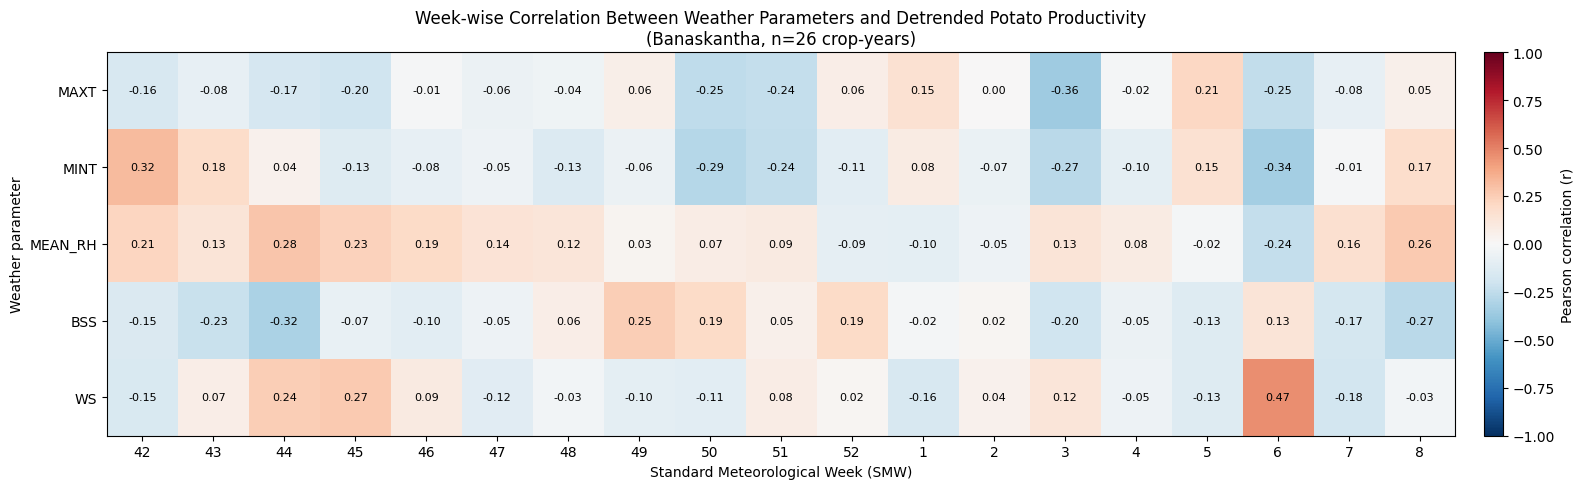

,42,43,44,45,46,47,48,49,50,51,52,1,2,3,4,5,6,7,8
TMAX,-0.16,-0.08,-0.17,-0.20,-0.01,-0.06,-0.04,0.06,-0.25,-0.24,0.06,0.15,0.00,-0.36,-0.02,0.21,-0.25,-0.08,0.05
TMIN,0.32,0.18,0.04,-0.13,-0.08,-0.05,-0.13,-0.06,-0.29,-0.24,-0.11,0.08,-0.07,-0.27,-0.10,0.15,-0.34,-0.01,0.17
RH,0.21,0.13,0.28,0.23,0.19,0.14,0.12,0.03,0.07,0.09,-0.09,-0.10,-0.05,0.13,0.08,-0.02,-0.24,0.16,0.26
BSS,-0.15,-0.23,-0.32,-0.07,-0.10,-0.05,0.06,0.25,0.19,0.05,0.19,-0.02,0.02,-0.20,-0.05,-0.13,0.13,-0.17,-0.27
WS,-0.15,0.07,0.24,0.27,0.09,-0.12,-0.03,-0.10,-0.11,0.08,0.02,-0.16,0.04,0.12,-0.05,-0.13,0.47,-0.18,-0.03


In [14]:
import matplotlib.pyplot as plt

DISTRICT = 'Banaskantha'
param_label = {'TMAX':'MAXT', 'TMIN':'MINT', 'RH':'MEAN_RH', 'BSS':'BSS', 'WS':'WS'}
week_labels = [str(w) for w in season_weeks]

corr = pd.DataFrame(index=varnames, columns=season_weeks, dtype=float)
for v in varnames:
    for wk in season_weeks:
        corr.loc[v, wk] = df[f'{v}_{wk}'].corr(df['Yield_detrended'])

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(season_weeks)))
ax.set_xticklabels(week_labels)
ax.set_yticks(range(len(varnames)))
ax.set_yticklabels([param_label[v] for v in varnames])
ax.set_xlabel('Standard Meteorological Week (SMW)')
ax.set_ylabel('Weather parameter')
ax.set_title('Week-wise Correlation Between Weather Parameters and Detrended Potato Productivity\n(%s, n=%d crop-years)' % (DISTRICT, len(df)))

for i in range(len(varnames)):
    for j in range(len(season_weeks)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Pearson correlation (r)')
plt.tight_layout()
plt.savefig(f'{DISTRICT}_weekwise_correlation.png', dpi=150)
plt.show()

corr.round(2)

## Step 4 — Feature selection + model helper functions

In [ ]:
def aic_from_resid(y_true, y_pred, k):
    resid = y_true - y_pred
    sse = max(np.sum(resid**2), 1e-6)
    return n*np.log(sse/n) + 2*k

def select_features(Xs, yv, method, K):
    if method == 'Mutual Information':
        mi = mutual_info_regression(Xs, yv, random_state=42)
        idx = np.argsort(mi)[::-1][:K]
    elif method == 'SelectKBest':
        skb = SelectKBest(score_func=f_regression, k=K).fit(Xs, yv)
        idx = np.argsort(skb.scores_)[::-1][:K]
    elif method == 'RFE':
        rfe = RFE(estimator=LinearRegression(), n_features_to_select=K).fit(Xs, yv)
        idx = np.where(rfe.support_)[0]
    return idx

models = {
    'SLR':          (LinearRegression(), {}),
    'Ridge':        (Ridge(), {'alpha':[0.1,1,5,10,20]}),
    'Lasso':        (Lasso(max_iter=5000), {'alpha':[0.01,0.05,0.1,0.5,1]}),
    'ElasticNet':   (ElasticNet(max_iter=5000), {'alpha':[0.01,0.1,0.5,1], 'l1_ratio':[0.2,0.5,0.8]}),
    'SVR':          (SVR(), {'kernel':['linear','rbf'], 'C':[1,5,10], 'epsilon':[0.1,0.2]}),
    'KNN':          (KNeighborsRegressor(), {'n_neighbors':[2,3,4], 'weights':['uniform','distance']}),
    'RandomForest': (RandomForestRegressor(random_state=42), {'n_estimators':[100,200], 'max_depth':[2,3,5]}),
    'XGBoost':      (XGBRegressor(random_state=42, verbosity=0), {'n_estimators':[50,100], 'learning_rate':[0.05,0.1], 'max_depth':[2,3]}),
    'ANN':          (MLPRegressor(max_iter=5000, random_state=42), {'hidden_layer_sizes':[(4,),(6,),(3,2)], 'alpha':[0.01,0.1,1.0]}),
}

## Step 5 — Run: tune each model (5-fold CV) then honestly evaluate with LOOCV

In [16]:
from sklearn.model_selection import LeaveOneOut, KFold, RandomizedSearchCV, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression, RFE
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# Helper functions
def aic_from_resid(y_true, y_pred, k):
    resid = y_true - y_pred
    sse = max(np.sum(resid**2), 1e-6)
    return n*np.log(sse/n) + 2*k

def select_features(Xs, yv, method, K):
    if method == 'Mutual Information':
        mi = mutual_info_regression(Xs, yv, random_state=42)
        idx = np.argsort(mi)[::-1][:K]
    elif method == 'SelectKBest':
        skb = SelectKBest(score_func=f_regression, k=K).fit(Xs, yv)
        idx = np.argsort(skb.scores_)[::-1][:K]
    elif method == 'RFE':
        rfe = RFE(estimator=LinearRegression(), n_features_to_select=K).fit(Xs, yv)
        idx = np.where(rfe.support_)[0]
    return idx

models = {
    'SLR':          (LinearRegression(), {}),
    'Ridge':        (Ridge(), {'alpha':[0.1,1,5,10,20]}),
    'Lasso':        (Lasso(max_iter=5000), {'alpha':[0.01,0.05,0.1,0.5,1]}),
    'ElasticNet':   (ElasticNet(max_iter=5000), {'alpha':[0.01,0.1,0.5,1], 'l1_ratio':[0.2,0.5,0.8]}),
    'SVR':          (SVR(), {'kernel':['linear','rbf'], 'C':[1,5,10], 'epsilon':[0.1,0.2]}),
    'KNN':          (KNeighborsRegressor(), {'n_neighbors':[2,3,4], 'weights':['uniform','distance']}),
    'RandomForest': (RandomForestRegressor(random_state=42), {'n_estimators':[100,200], 'max_depth':[2,3,5]}),
    'XGBoost':      (XGBRegressor(random_state=42, verbosity=0), {'n_estimators':[50,100], 'learning_rate':[0.05,0.1], 'max_depth':[2,3]}),
    'ANN':          (MLPRegressor(max_iter=5000, random_state=42), {'hidden_layer_sizes':[(4,),(6,),(3,2)], 'alpha':[0.01,0.1,1.0]}),
}

loo = LeaveOneOut()
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for K in [8, 10]:
    for method in ['Mutual Information', 'SelectKBest', 'RFE']:
        idx = select_features(Xs_all, yv, method, K)
        feats = [feat_cols[i] for i in idx]
        X = Xs_all[:, idx]
        for mname, (est, grid) in models.items():
            try:
                if grid:
                    rs = RandomizedSearchCV(est, grid, n_iter=6, cv=kf5, scoring='r2', random_state=42, n_jobs=-1)
                    rs.fit(X, yv)
                    best = rs.best_estimator_
                else:
                    best = est
                pred_loo = cross_val_predict(best, X, yv, cv=loo)
                r2 = r2_score(yv, pred_loo)
                rmse = np.sqrt(mean_squared_error(yv, pred_loo))
                mae = mean_absolute_error(yv, pred_loo)
                results.append((mname, method, K, r2, aic_from_resid(yv, pred_loo, K+1), rmse, mae, feats))
            except Exception:
                pass

res_df = pd.DataFrame(results, columns=['Model','FeatureSelection','K','R2','AIC','RMSE','MAE','Features'])
best_per_model = res_df.loc[res_df.groupby('Model')['R2'].idxmax()].sort_values('R2', ascending=False)
best_per_model[['Model','FeatureSelection','Features','K','R2','AIC','RMSE','MAE']].round(3)

,Model,FeatureSelection,Features,K,R2,AIC,RMSE,MAE
49,SVR,RFE,"[BSS_44, WS_44, WS_45, BSS_49, TMIN_50, TMIN_5...",10,0.732,26.138,1.083,0.937
45,SLR,RFE,"[BSS_44, WS_44, WS_45, BSS_49, TMIN_50, TMIN_5...",10,0.714,27.856,1.119,0.922
46,Ridge,RFE,"[BSS_44, WS_44, WS_45, BSS_49, TMIN_50, TMIN_5...",10,0.714,27.860,1.119,0.922
48,ElasticNet,RFE,"[BSS_44, WS_44, WS_45, BSS_49, TMIN_50, TMIN_5...",10,0.709,28.282,1.128,0.927
47,Lasso,RFE,"[BSS_44, WS_44, WS_45, BSS_49, TMIN_50, TMIN_5...",10,0.699,29.132,1.147,0.946
53,ANN,RFE,"[BSS_44, WS_44, WS_45, BSS_49, TMIN_50, TMIN_5...",10,0.490,42.868,1.494,1.280
14,KNN,SelectKBest,"[WS_6, Lag1_YieldAnom, TMAX_3, TMIN_6, BSS_44,...",8,0.230,49.592,1.836,1.461
16,XGBoost,SelectKBest,"[WS_6, Lag1_YieldAnom, TMAX_3, TMIN_6, BSS_44,...",8,0.013,56.043,2.078,1.629
15,RandomForest,SelectKBest,"[WS_6, Lag1_YieldAnom, TMAX_3, TMIN_6, BSS_44,...",8,-0.007,56.564,2.099,1.644


## Step 6 — Best model's selected features + final predicted yield (trend added back)

In [17]:
top = res_df.sort_values('R2', ascending=False).iloc[0]
print("Best model:", top['Model'], "| Feature Selection:", top['FeatureSelection'], "| K:", top['K'])
print("R2 =", round(top['R2'],3), "| AIC =", round(top['AIC'],2), "| RMSE =", round(top['RMSE'],3), "| MAE =", round(top['MAE'],3))
print("\nSelected features:", top['Features'])

# Refit best model on selected features, predict on full data, add trend back for final yield
idx = select_features(Xs_all, yv, top['FeatureSelection'], top['K'])
X_best = Xs_all[:, idx]
est, grid = models[top['Model']]
if grid:
    rs = RandomizedSearchCV(est, grid, n_iter=6, cv=kf5, scoring='r2', random_state=42, n_jobs=-1).fit(X_best, yv)
    final_model = rs.best_estimator_
else:
    final_model = est.fit(X_best, yv)

pred_detrended = final_model.predict(X_best)
df['Predicted_Yield_final'] = pred_detrended + df['Trend']
df[['CropYear','Yield','Predicted_Yield_final']].round(2)

Best model: SVR | Feature Selection: RFE | K: 10
R2 = 0.732 | AIC = 26.14 | RMSE = 1.083 | MAE = 0.937

Selected features: ['BSS_44', 'WS_44', 'WS_45', 'BSS_49', 'TMIN_50', 'TMIN_52', 'TMAX_5', 'BSS_5', 'TMIN_6', 'WS_8']


,CropYear,Yield,Predicted_Yield_final
0,1997,27.22,28.36
1,1998,28.29,28.49
2,1999,25.00,26.17
3,2000,25.06,24.58
4,2001,30.67,29.94
5,2002,26.32,26.12
6,2003,25.00,26.84
7,2004,22.50,23.07
8,2005,28.50,28.78
9,2006,28.00,27.75
